# Foundations of Linear Algebra and Deep Learning: Tokenizers

In [1]:
# Instalação das dependências necessárias
%pip install numpy torch matplotlib

import numpy as np
import torch
import matplotlib.pyplot as plt
import collections
import re

# Fixando as seeds para reprodutibilidade
np.random.seed(42)
torch.manual_seed(42)

Note: you may need to restart the kernel to use updated packages.


## 1. Contextualização histórica e motivação

Esta seção cobre o problema da representação de texto para máquinas, desde a compressão de dados até a tokenização moderna, e importa porque algoritmos computacionais processam apenas números, não texto.

Computadores operam exclusivamente com números, o que torna a conversão de texto uma etapa obrigatória no processamento de linguagem natural (NLP). Historicamente, a tabela ASCII (com 8 bits) e posteriormente o UTF-8 foram utilizados para mapear caracteres em bytes. No entanto, em modelos de aprendizado de máquina, abordagens ingênuas falham: a tokenização em nível de caractere exige muitas etapas autorregressivas (5 a 6 caracteres por palavra no idioma inglês), tornando a geração lenta e apresentando baixa representação semântica. Por outro lado, a tokenização em nível de palavra exige um vocabulário infinito e sofre com erros gramaticais, rotulando frequentemente palavras úteis como `UNK` (desconhecidas), o que resulta em perda substancial de informação.

A solução surge com a tokenização em nível de subpalavra, sendo o *Byte-Pair Encoding* (BPE) o algoritmo dominante. O BPE foi criado originalmente em 1994 por Philip Gage como um algoritmo de compressão de dados. O método busca padrões frequentes e os comprime em novos símbolos. Atualmente (2024-2025), o BPE e suas variantes, como o *SentencePiece*, são a base de praticamente todos os grandes modelos de linguagem (LLMs), incluindo as famílias GPT e LLaMA. O processo mapeia raízes de palavras para os mesmos tokens, garantindo alta representação semântica e reduzindo o tamanho das sequências de entrada para as redes neurais.

## 2. Intuição e visualização

Esta seção constrói a intuição estatística por trás da aglomeração de caracteres em subpalavras, e importa para ilustrar como a frequência de coocorrência define a criação de novos tokens.

O algoritmo BPE funciona através da contagem da frequência de caracteres e, iterativamente, aglutina os pares de símbolos mais frequentes. Se o texto apresenta a sequência "c a r a m e l a d o" múltiplas vezes, e os caracteres "c" e "a" formam o par mais comum, eles são fundidos no novo token "ca". O processo repete-se até que o vocabulário atinja um tamanho pré-definido pelo pesquisador. A intuição probabilística é simples: elementos que ocorrem juntos com alta frequência no idioma possuem alta probabilidade conjunta e devem ser tratados como uma unidade semântica única.

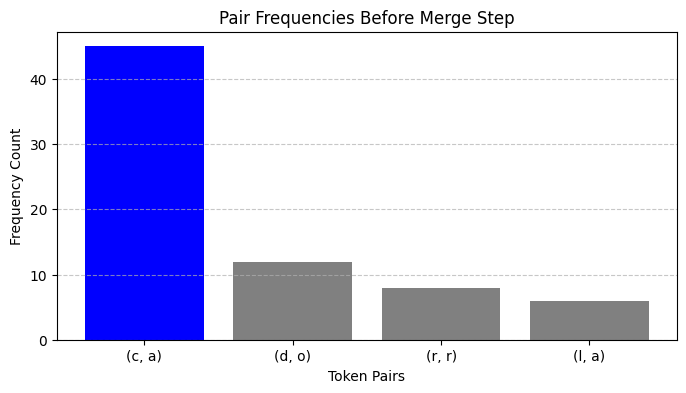

In [2]:
# Intuição visual: Frequência de pares antes de uma fusão
pairs = ['(c, a)', '(d, o)', '(r, r)', '(l, a)']
frequencies = [45, 12, 8, 6]

plt.figure(figsize=(8, 4))
plt.bar(pairs, frequencies, color=['blue', 'gray', 'gray', 'gray'])
plt.title('Pair Frequencies Before Merge Step')
plt.xlabel('Token Pairs')
plt.ylabel('Frequency Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Teoria formal

Esta seção apresenta as definições formais e equações que regem a criação do vocabulário, e importa para garantir o rigor matemático no entendimento do mapeamento texto-número.

Seja $C$ um corpus de texto e $V$ o vocabulário inicial composto pelos caracteres (ou bytes) únicos presentes em $C$. O algoritmo BPE busca um novo token $t_{new}$ através da concatenação de dois tokens adjacentes $x, y \in V$. A função objetivo do passo de fusão em BPE maximiza a frequência empírica $f(x,y)$:

$$ t_{new} = \arg\max_{x,y \in V} f(x, y) $$

Após a descoberta de $t_{new}$, o vocabulário é atualizado:

$$ V_{i+1} = V_i \cup \{t_{new}\} $$

A limitação primária desta definição teórica é a premissa de que os espaços separam as palavras. Nas línguas não-latinas, como Chinês ou Tailandês, onde as palavras não são delimitadas por espaços, essa modelagem requer pré-processamento adicional ou a utilização do algoritmo *SentencePiece*, que trata o espaço como um caractere normal. Além disso, nota-se que o BPE é um algoritmo guloso (*greedy*); ele maximiza a compressão localmente a cada iteração, o que não garante o menor vocabulário global absoluto para um determinado comprimento de sequência.

## 4. Algoritmos

Esta seção exibe o pseudocódigo legível do BPE, e importa porque traduz a teoria de contagem e fusão em passos computacionais reproduzíveis.

```text
Entrada: Corpus C, Tamanho alvo do Vocabulário N
V = {obter_caracteres_unicos(C)}

Enquanto |V| < N:
    pares_adjacentes = inicializar_dicionario()
    
    Para cada palavra em C:
        Para cada par de tokens adjacentes na palavra:
            pares_adjacentes[par] += frequência_da_palavra
            
    melhor_par = encontrar_maximo(pares_adjacentes)
    V = V + melhor_par
    C = substituir_em_todas_as_palavras(C, melhor_par)
    
Retornar V, C
```

**Explicação dos passos:**
1. O algoritmo inicia separando o corpus em palavras e contabilizando os caracteres individuais de cada palavra para compor o vocabulário inicial.
2. Um laço de repetição ocorre até que o tamanho do vocabulário `|V|` atinja o hiperparâmetro `N`.
3. Calcula-se a frequência de todos os pares de tokens adjacentes no corpus.
4. O par com maior número de ocorrências é selecionado.
5. O novo par é adicionado ao vocabulário, e todas as ocorrências desses dois tokens no corpus original são substituídas pelo novo token fundido.

## 5. Implementação from scratch

Esta seção implementa a lógica central de fusão de tokens do BPE utilizando ferramentas nativas do Python, e importa para revelar o funcionamento interno da construção de dicionários sem o encapsulamento de frameworks complexos.

In [3]:
def get_stats(vocab: dict) -> dict:
    """
    Conta a frequência de pares adjacentes de tokens em um vocabulário.
    
    Args:
        vocab (dict): Dicionário mapeando palavras (tuplas de caracteres) para suas frequências.
        
    Returns:
        dict: Mapeamento de pares de tokens para contagem de ocorrências.
    """
    pairs = collections.defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[symbols[i], symbols[i+1]] += freq
    return pairs

def merge_vocab(pair: tuple, v_in: dict) -> dict:
    """
    Funde o par de tokens mais frequente em todas as palavras do vocabulário.
    
    Args:
        pair (tuple): O par de tokens a ser fundido (e.g., ('c', 'a')).
        v_in (dict): Vocabulário atual.
        
    Returns:
        dict: Novo vocabulário com o par fundido.
    """
    v_out = {}
    bigram = re.escape(' '.join(pair))
    # Expressão regular que encontra o par isolado por espaços
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

# Teste da implementação
vocab = {'l o w < / w >': 5, 'l o w e r < / w >': 2, 
         'n e w e s t < / w >': 6, 'w i d e s t < / w >': 3}

num_merges = 5
for i in range(num_merges):
    pairs = get_stats(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    print(f"Merge {i+1}: {best} -> {''.join(best)}")

# Asserção garantindo que a fusão altera o comprimento dos tokens originais
assert 'e s t < / w >' not in vocab.keys(), "Os tokens individuais devem ser agrupados"
print("\nVocabulário final após fusões:", vocab)

Merge 1: ('<', '/') -> </
Merge 2: ('</', 'w') -> </w
Merge 3: ('</w', '>') -> </w>
Merge 4: ('e', 's') -> es
Merge 5: ('es', 't') -> est

Vocabulário final após fusões: {'l o w </w>': 5, 'l o w e r </w>': 2, 'n e w est </w>': 6, 'w i d est </w>': 3}


## 6. Implementação em PyTorch

Esta seção demonstra o papel da API do PyTorch em lidar com os IDs numéricos gerados pelos tokenizadores, e importa porque conecta a etapa de pré-processamento discreto às matrizes contínuas consumidas pelas redes neurais.

Os tokenizadores transformam texto em uma lista de inteiros (índices) correspondentes ao vocabulário. Computadores não entendem texto; os algoritmos precisam processar números. No PyTorch, esses índices alimentam um espaço denso através da camada `torch.nn.Embedding` (que atua como uma lookup table para a primeira camada Multi-Layer Perceptron ou Transformer da rede).

In [4]:
class TokenEmbeddingLayer(torch.nn.Module):
    """
    Camada que recebe IDs dos tokens (saída do Tokenizer) e os projeta
    em um espaço vetorial contínuo (Embedding Space).
    """
    def __init__(self, vocab_size: int, embedding_dim: int):
        super(TokenEmbeddingLayer, self).__init__()
        # API do PyTorch que atua como uma Lookup Table (Tabela de Pesquisa).
        # Cada token_id apontará para um vetor de tamanho 'embedding_dim'.
        self.embedding = torch.nn.Embedding(num_embeddings=vocab_size, 
                                            embedding_dim=embedding_dim)
        
    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        return self.embedding(token_ids)

# Simulando a saída do nosso tokenizador de tamanho V=14 e H=512
vocab_size = 14
hidden_dim = 512

# Sequência gerada pelo Tokenizer (exemplo: 6 tokens em 1 sample de batch)
token_ids_batch = torch.tensor([[2, 5, 1, 8, 3, 4]])

model = TokenEmbeddingLayer(vocab_size, hidden_dim)
dense_vectors = model(token_ids_batch)

print(f"Input shape (Batch, Seq_Length): {token_ids_batch.shape}")
print(f"Output shape (Batch, Seq_Length, Hidden_Dim): {dense_vectors.shape}")

# Teste garantindo a equivalência dimensional correta para redes profundas
assert dense_vectors.shape == (1, 6, hidden_dim), "Dimensões não correspondem"
print("Embedding transformado com sucesso!")

Input shape (Batch, Seq_Length): torch.Size([1, 6])
Output shape (Batch, Seq_Length, Hidden_Dim): torch.Size([1, 6, 512])
Embedding transformado com sucesso!


## 7. Experimentos e análise

Esta seção executa experimentos variando o número de fusões no BPE para demonstrar o compromisso entre o tamanho do vocabulário e a eficiência da representação sequencial, e importa para ilustrar como os hiperparâmetros afetam a etapa de modelagem.

O experimento a seguir utiliza um pequeno corpus sintetizado para rastrear como o comprimento total da representação decresce à medida que o número de tokens do vocabulário ($|V|$) aumenta. Na prática, se $|V|$ for pequeno, a sequência permanece grande (como em nível de caractere), aumentando os passos autorregressivos. Se $|V|$ for muito grande, tokens raros recebem pouca atualização em seus embeddings, além de introduzirem o problema da "memória ociosa". Para diagnosticar falhas na prática, observe se as sequências geradas são inviavelmente grandes ou se uma alta porcentagem das palavras cruza o limiar de token não reconhecido (`UNK`) — o BPE visa justamente contornar o excesso de `UNK` garantindo a decomposição em subpalavras ou, em última instância, caracteres.

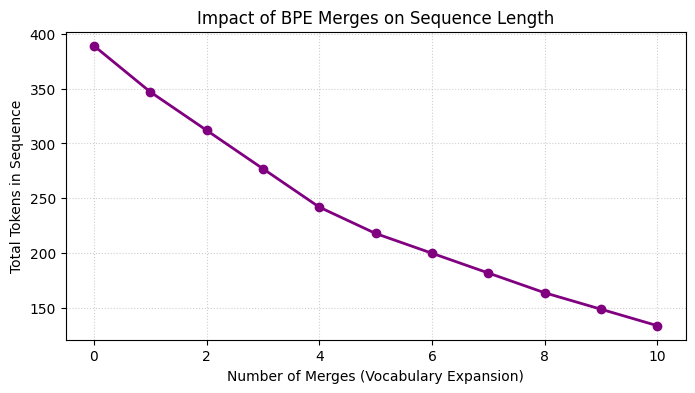

Comprimento inicial: 389 tokens
Comprimento final: 134 tokens
Redução de sequência: 65.6%


In [5]:
def count_sequence_length(vocab: dict) -> int:
    """Calcula o comprimento total da sequência de tokens."""
    return sum(len(word.split()) * freq for word, freq in vocab.items())

corpus_vocab = {'e s p e r a n c a < / w >': 10, 'e s p e r a r < / w >': 5, 
                'd a n c a < / w >': 8, 'a n d a n d o < / w >': 12}

history_merges = []
history_lengths = []

vocab_exp = corpus_vocab.copy()
history_lengths.append(count_sequence_length(vocab_exp))
history_merges.append(0)

# Experimento: 10 Fusões
for i in range(1, 11):
    pairs = get_stats(vocab_exp)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab_exp = merge_vocab(best, vocab_exp)
    history_merges.append(i)
    history_lengths.append(count_sequence_length(vocab_exp))

plt.figure(figsize=(8, 4))
plt.plot(history_merges, history_lengths, marker='o', color='purple', linewidth=2)
plt.title('Impact of BPE Merges on Sequence Length')
plt.xlabel('Number of Merges (Vocabulary Expansion)')
plt.ylabel('Total Tokens in Sequence')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Comprimento inicial: {history_lengths[0]} tokens")
print(f"Comprimento final: {history_lengths[-1]} tokens")
print(f"Redução de sequência: {((history_lengths[0] - history_lengths[-1]) / history_lengths[0] * 100):.1f}%")

## 8. Conexões com ML moderno

Esta seção vincula o BPE aos sistemas de aprendizado de máquina em uso massivo atualmente, e importa para justificar a centralidade desta técnica nas arquiteturas baseadas em Transformers em 2025.

Em 2025, o BPE continua sendo o fundamento absoluto para modelos como LLMs (Grandes Modelos de Linguagem). Como visto no treinamento do LLaMA, a robustez semântica fornecida pelo BPE é ampliada aumentando-se posições exclusivas no vocabulário de tamanho fixo para idiomas sub-representados, contornando a falha original de representação assimétrica da língua inglesa (que precisa de poucos tokens para geração, cerca de 1.3 por palavra) contra línguas não-latinas. Em arquiteturas baseadas em *Transformers*, algoritmos de tokenização alimentam diretamente o modelo de Embedding sem o qual as matrizes de Atenção não operam, justificando sua extrema necessidade na IA Generativa.

* **SentencePiece (Kudo & Richardson, 2018):** Estende o conceito de subpalavras eliminando a suposição de separação por espaços, crucial para idiomas multilíngues como chinês e tailandês.
* **BPE in NLP (Sennrich et al., 2015):** Adaptou formalmente o BPE (inventado por Gage) para tradução de máquina em NLP, reduzindo o problema de "Out of Vocabulary" (OOV).

## 9. Exercícios

Esta seção fornece desafios de verificação para fixação e expansão do conceito de geração de tokens, e importa para garantir o domínio prático do ferramental introduzido.

### Exercícios Resolvidos

**Exercício 1:** Por que a tokenização exclusiva a nível de caractere reduz substancialmente o desempenho na geração de texto em LLMs?

*Resolução:* Modelos de geração de texto operam de maneira autorregressiva (geram o token temporal $t+1$ condicionado a $t$). O idioma inglês tem, em média, 5 a 6 caracteres por palavra. Produzir uma frase de 10 palavras exigiria 50-60 etapas sequenciais caras, além de o caractere isolado possuir baixíssima representatividade semântica para os cálculos do espaço latente.

**Exercício 2:** Como a tokenização por subpalavras aborda palavras desconhecidas e erros gramaticais em comparação com a tokenização em nível de palavra?

*Resolução:* A tokenização por palavras força itens não cadastrados no dicionário fixo a mapearem para o token de perda `<UNK>`, perdendo totalmente a informação da frase. A tokenização por subpalavra é robusta pois qualquer erro de digitação deforma apenas um sufixo ou prefixo (e.g. perdendo os 50% de informação local do caractere errado), mas mantém o token principal da subpalavra derivado da raiz preservado e semanticamente íntegro.

**Exercício 3:** Explique, usando o algoritmo BPE, o impacto do método na preservação de radicais verbais na mesma família etimológica.

*Resolução:* Palavras derivadas (ex: "anda", "andar", "andando") são separadas frequentemente com a subpalavra da raiz em evidência. O token para "anda" persiste entre todos os tempos verbais. O algoritmo assegura que variações sejam meras adições de tokens de desinências menores (como "ndo" ou "r"), permitindo que a rede neural capture a semântica principal instantaneamente.

### Desafios Abertos

**Desafio 1 (Semântica Inter-idiomas):**
Implemente uma modificação no código "from scratch" fornecido que trate explicitamente o símbolo de espaço como o caractere especial `_` (underscore). Observe como isso simula as raízes do SentencePiece para línguas sem segmentação nativa, conforme discutido para Chinês e Tailandês.

*Dica: Anexe o caractere `_` no início da string da palavra antes de dividi-la e conte o `_` como um símbolo do vocabulário base.*

**Desafio 2 (Byte-Level BPE):**
Modifique o vocabulário básico do BPE para que ele se origine obrigatoriamente de 256 bytes possíveis do UTF-8, garantindo teoricamente que o token `UNK` jamais precise ser evocado.

*Dica: Utilize a função `word.encode("utf-8")` para iterar sobre os bytes brutos do Python em vez de caracteres isolados no processo de coleta estatística.*

## Referências

* Gage, P. (1994). A new algorithm for data compression. *The C Users Journal*, 12(2), 23-38.
* Kudo, T., & Richardson, J. (2018). SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing. *arXiv preprint arXiv:1808.06226*.
* Sennrich, R., Haddow, B., & Birch, A. (2015). Neural machine translation of rare words with subword units. *arXiv preprint arXiv:1508.07909*.